## Online Payments Fraud Detection

Life Cycle of Machine Learning Project
 1. Understanding Probelm Statement
 2. Data Collection
 3. Data Check to Perform
 4. Exploraty Data Analaysis
 5. Data Preprocessing
 6. Model Training
 7. Select Best Model

 1. Understanding Probelm Statement : This Project understand is any customer payment(yes/no), it's affected other variable such a source","browser","sex","age" etc.
it's Online Payments Fraud Detection Machine Learining Project. Model will predict Customer is fraud or not fraud.
It's Helps to make decision Online Bussiness Owner to identify Real and Fraud Customer

 2. Data Collection : This dataset collect from kaggle.
  - Dataset Source -  https://www.kaggle.com/datasets/vbinh002/fraud-ecommerce

2.1 Import Data and Library

In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [66]:
## Load the dataset
df = pd.read_csv('data\Data.csv')

In [67]:
## show dataset top 5 rows
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [68]:
## dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


In [69]:
## dataset shape
df.shape

(151112, 11)

dataset have 151112 rowa and 11 columns

In [70]:
## dataset columns
df.columns.to_list()

['user_id',
 'signup_time',
 'purchase_time',
 'purchase_value',
 'device_id',
 'source',
 'browser',
 'sex',
 'age',
 'ip_address',
 'class']

2.2 dataset Information  
 'user_id'              : unique usesr identifier <br>
 'signup_time'          : user account create time <br>
 'purchase_time'        : when did the user make the purchase time <br>
 'purchase_value'       : Transaction Amaount <br>
 'device_id'            : using which device user did the login <br>
 'source'               : how to come user(seo.ads etc) <br>
 'browser'              : which browser user use <br>
 'sex'                  : user gender(Male/Fmale) <br>
 'age'                  : user age <br>
 'ip_address'           : user ip address (internet protoccol Address) <br>
 'class'                : Target columns user fraud or normal <br>

3. Data Check to Perform

3.1 Check Missing Values

In [71]:
df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

There is no missing values in the dataset

3.2 Check Duplicate Values

In [72]:
df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

There is no duplicates values in the dataset

3.3 Cheak datatype

In [73]:
df.dtypes

user_id             int64
signup_time        object
purchase_time      object
purchase_value      int64
device_id          object
source             object
browser            object
sex                object
age                 int64
ip_address        float64
class               int64
dtype: object

3.4 Checking the number of unique values of each column

In [74]:
df.nunique()

user_id           151112
signup_time       151112
purchase_time     150679
purchase_value       122
device_id         137956
source                 3
browser                5
sex                    2
age                   58
ip_address        143512
class                  2
dtype: int64

 3.5 Check statistics of data set

In [75]:
df.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


## Exploraty Data Analaysis


In [76]:
## signup_time	purchase_time columns have object data type, we need to convert them to datetime data type
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

In [77]:
## unique values of categorical columns
for col in df.columns:
    if df[col].dtype == "O":
        print(f"{col}: {df[col].unique()}")

device_id: ['QVPSPJUOCKZAR' 'EOGFQPIZPYXFZ' 'YSSKYOSJHPPLJ' ... 'LYSFABUCPCGBA'
 'MEQHCSJUBRBFE' 'ZINIADFCLHYPG']
source: ['SEO' 'Ads' 'Direct']
browser: ['Chrome' 'Opera' 'Safari' 'IE' 'FireFox']
sex: ['M' 'F']


In [78]:
## define numerical and categorical columns
numerical_col = [feature for feature in df.columns if df[feature].dtype != "O"]
categorical_col = [feature for feature in df.columns if df[feature].dtype == "O"]

print(f"we have {len(numerical_col)} numerical feature {numerical_col}")
print(f"we have {len(categorical_col)} Categorical feature {categorical_col}")

we have 7 numerical feature ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'age', 'ip_address', 'class']
we have 4 Categorical feature ['device_id', 'source', 'browser', 'sex']


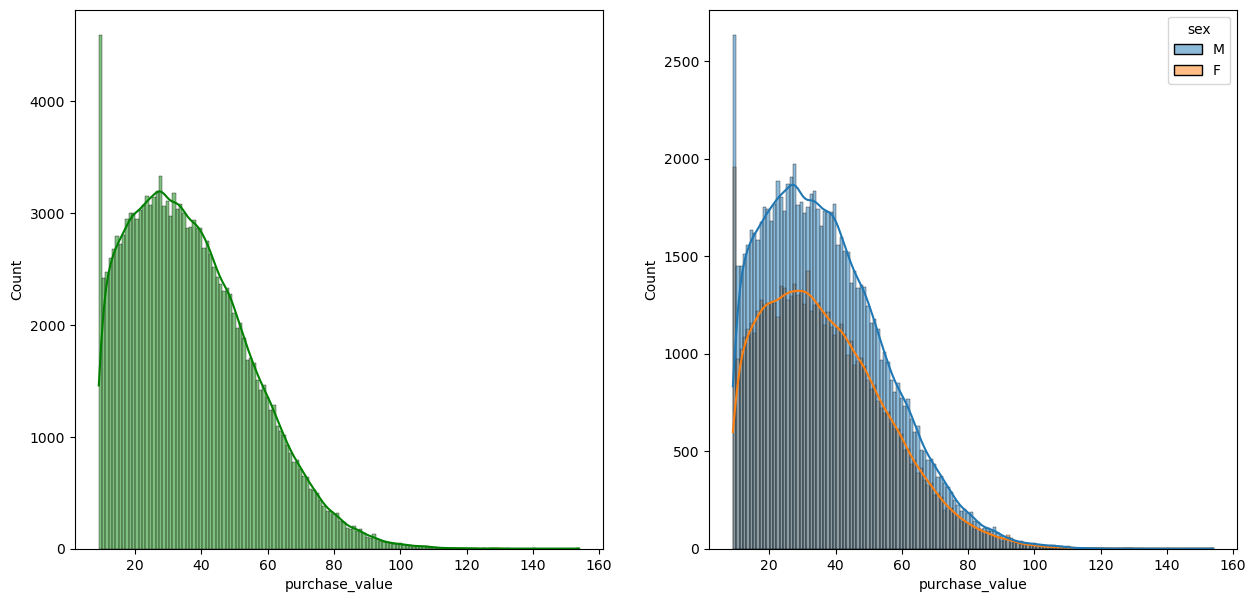

In [79]:
## hist plot for sex columns
fig,ax = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='purchase_value', kde=True, color = "g")
plt.subplot(122)            
sns.histplot(data=df, x='purchase_value',hue='sex', kde=True)
plt.show()

male customer purchase more than fmale

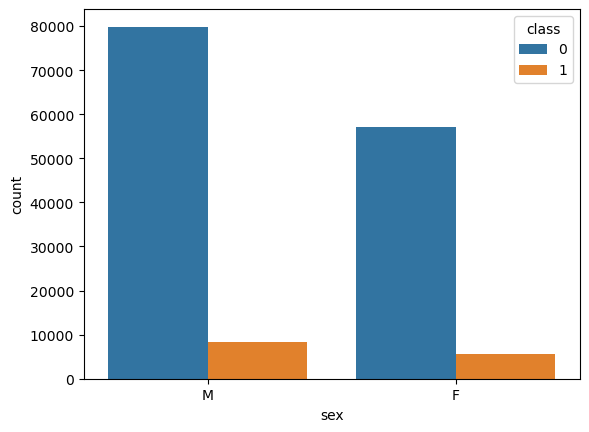

In [80]:
## check which sex customer have more fraud
sns.countplot(data=df, x='sex', hue='class')
plt.show()

showing the plot male customers have more fraud than female customers. <br>
it's normal because male customers purchase more .

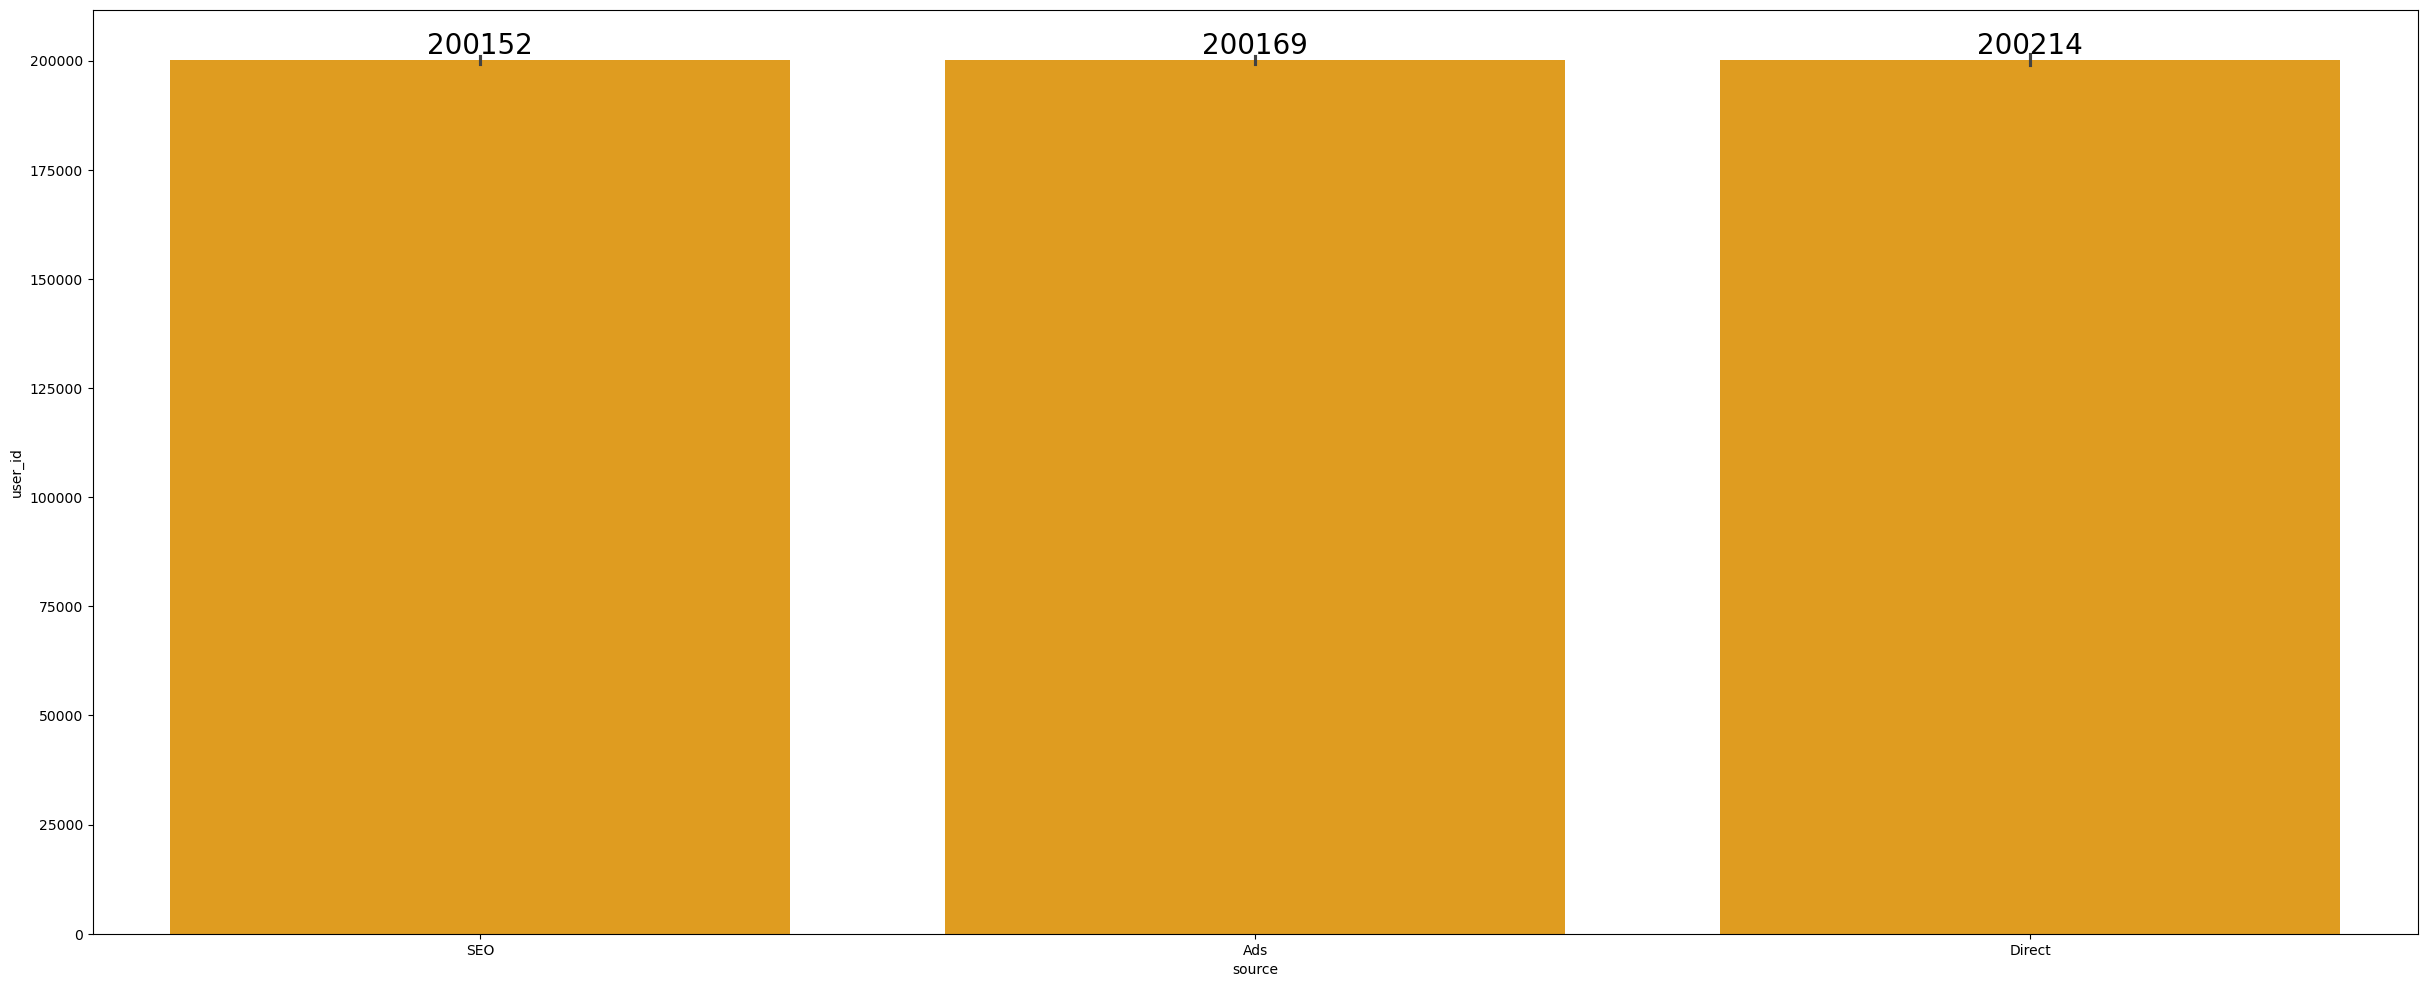

In [152]:
## check from which source customer come more
plot = sns.barplot(x = df['source'],y=df['user_id'],color="orange")
for container in plot.containers:
    plot.bar_label(container,color='black',size=20) 

plt.show()

both Source has same customer 

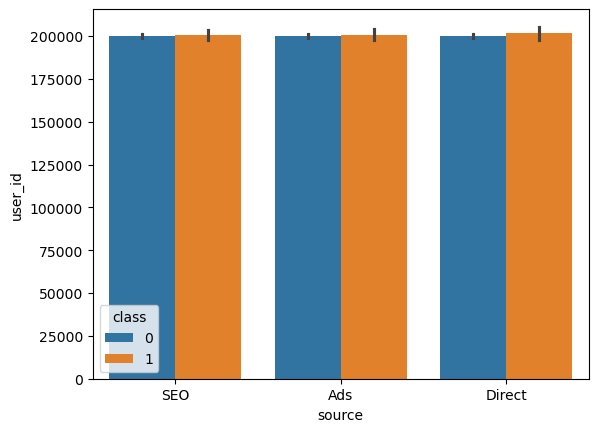

In [82]:
##check which source have more fraud
sns.barplot(data=df,x="source",y="user_id",hue="class")
plt.show()

every source has equal fraud 

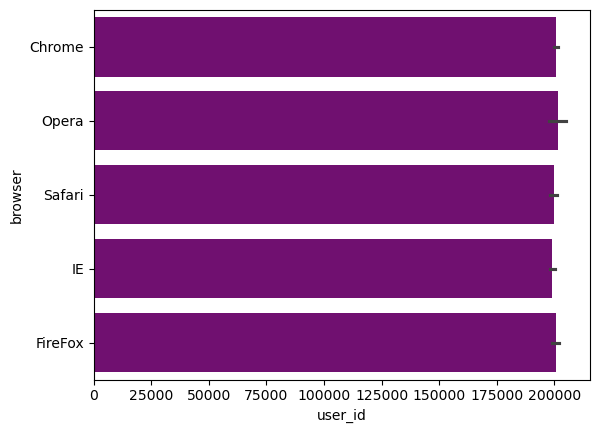

In [83]:
## check from which browser customer has more 
sns.barplot(data=df,y="browser",x="user_id",color="purple")
plt.show()


evrey browser  has same customer 

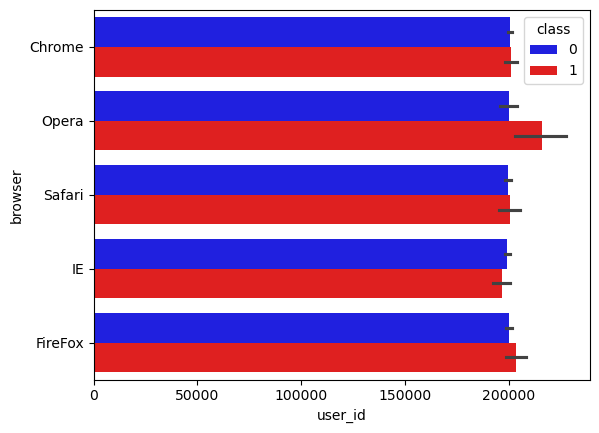

In [84]:
## check from which browser customer has more fraud
class_color = {0: 'blue', 1: 'red'}
sns.barplot(data=df,y="browser",x="user_id",hue="class",palette=class_color)
plt.show()

from opera browser fraud are come more, and after that Firefox

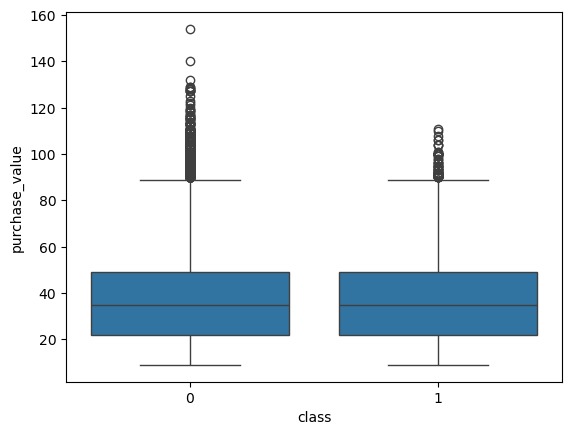

In [85]:
## how much effected customer purchase value for fraud and non fraud
sns.boxplot(data=df,x="class",y="purchase_value")
plt.show()

if any customer purchase values is more, it's not fraud. <br>
Normaly when purchas values is more customer fraud possibility is more but here we can see when purchase value is more, it's not fraud.<br>
so we can say that fraud customer purchase value is less than non fraud customer.<br>


In [86]:
## for analysis create a copy dataset
df_2 = df.copy()

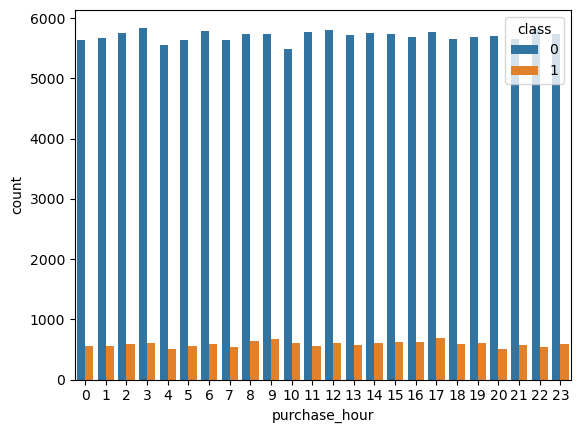

In [87]:
# which time of day have more fraud
df_2['purchase_hour'] = df_2['purchase_time'].dt.hour
sns.countplot(data=df_2, x='purchase_hour', hue='class')
plt.show()

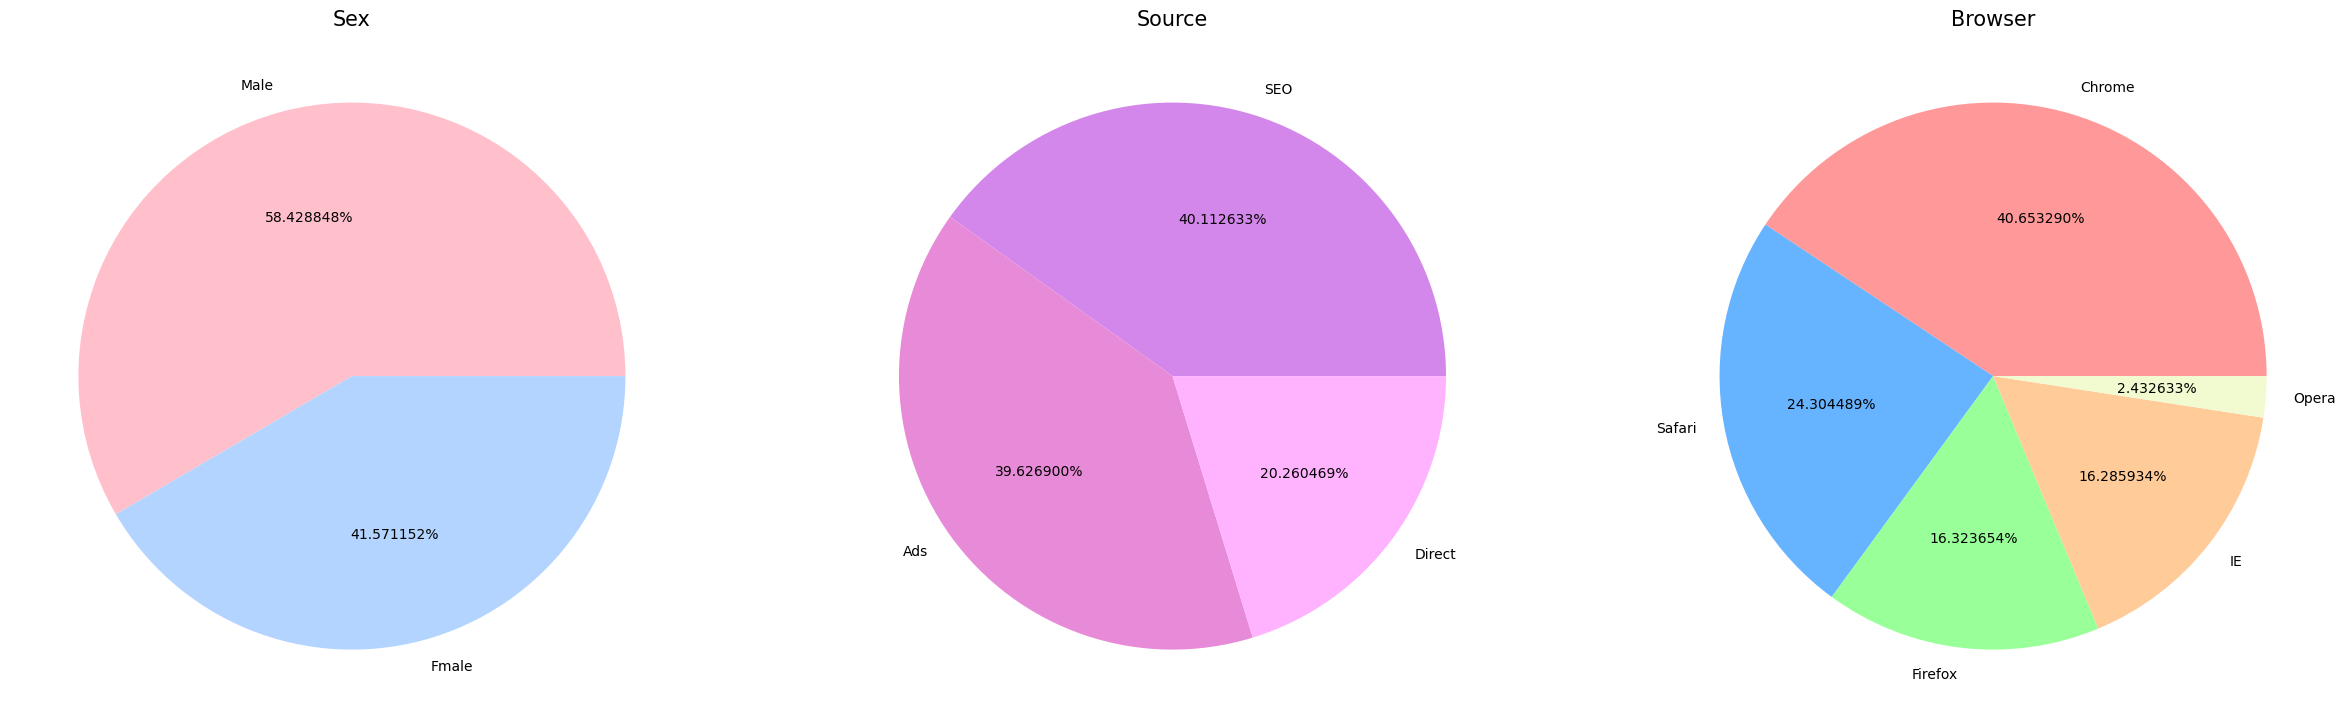

In [ ]:
##multiple analysis using pieplot
plt.rcParams["figure.figsize"] = (30,12)

plt.subplot(1,3,1)
size = df["sex"].value_counts()
labels="Male","Fmale"
color=["pink","#b3d4ff"]
plt.pie(size,colors=color,labels=labels,autopct="%2f%%")
plt.title("Sex",fontsize=15)


plt.subplot(1,3,2)
size2 = df['source'].value_counts()
labels = "SEO","Ads","Direct"
color = ["#d487eb","#e78ad8","#ffb3ff"]
plt.pie(size2,colors=color,labels=labels,autopct="%2f%%")
plt.title("Source",fontsize=15)

plt.subplot(1,3,3)
size3 = df['browser'].value_counts()
labels = "Chrome","Safari","Firefox","IE","Opera"
color = ["#ff9999","#66b3ff","#99ff99","#ffcc99","#f2fad0"]
plt.pie(size3,colors=color,labels=labels,autopct="%2f%%")
plt.title("Browser",fontsize=15)

plt.show()

Insight
- Male(58.42%) Customer is more than Fmale(41.57%) 
- Most Customer comers to SEO(40.13), After that Ads(39.62) and Direct(20.26) customer
- Customer use Chorme(40.65) most, than safari(24.30). Firefox and IE has equal(16.32-16.28) and opera(2.43)

# Deep Insight <br>
Opera Browser has less customer, and mostly fraud comes to opera Browser.<br>
It's mean's bussiness owner has to ignore opera browser customer

<Figure size 2500x800 with 0 Axes>

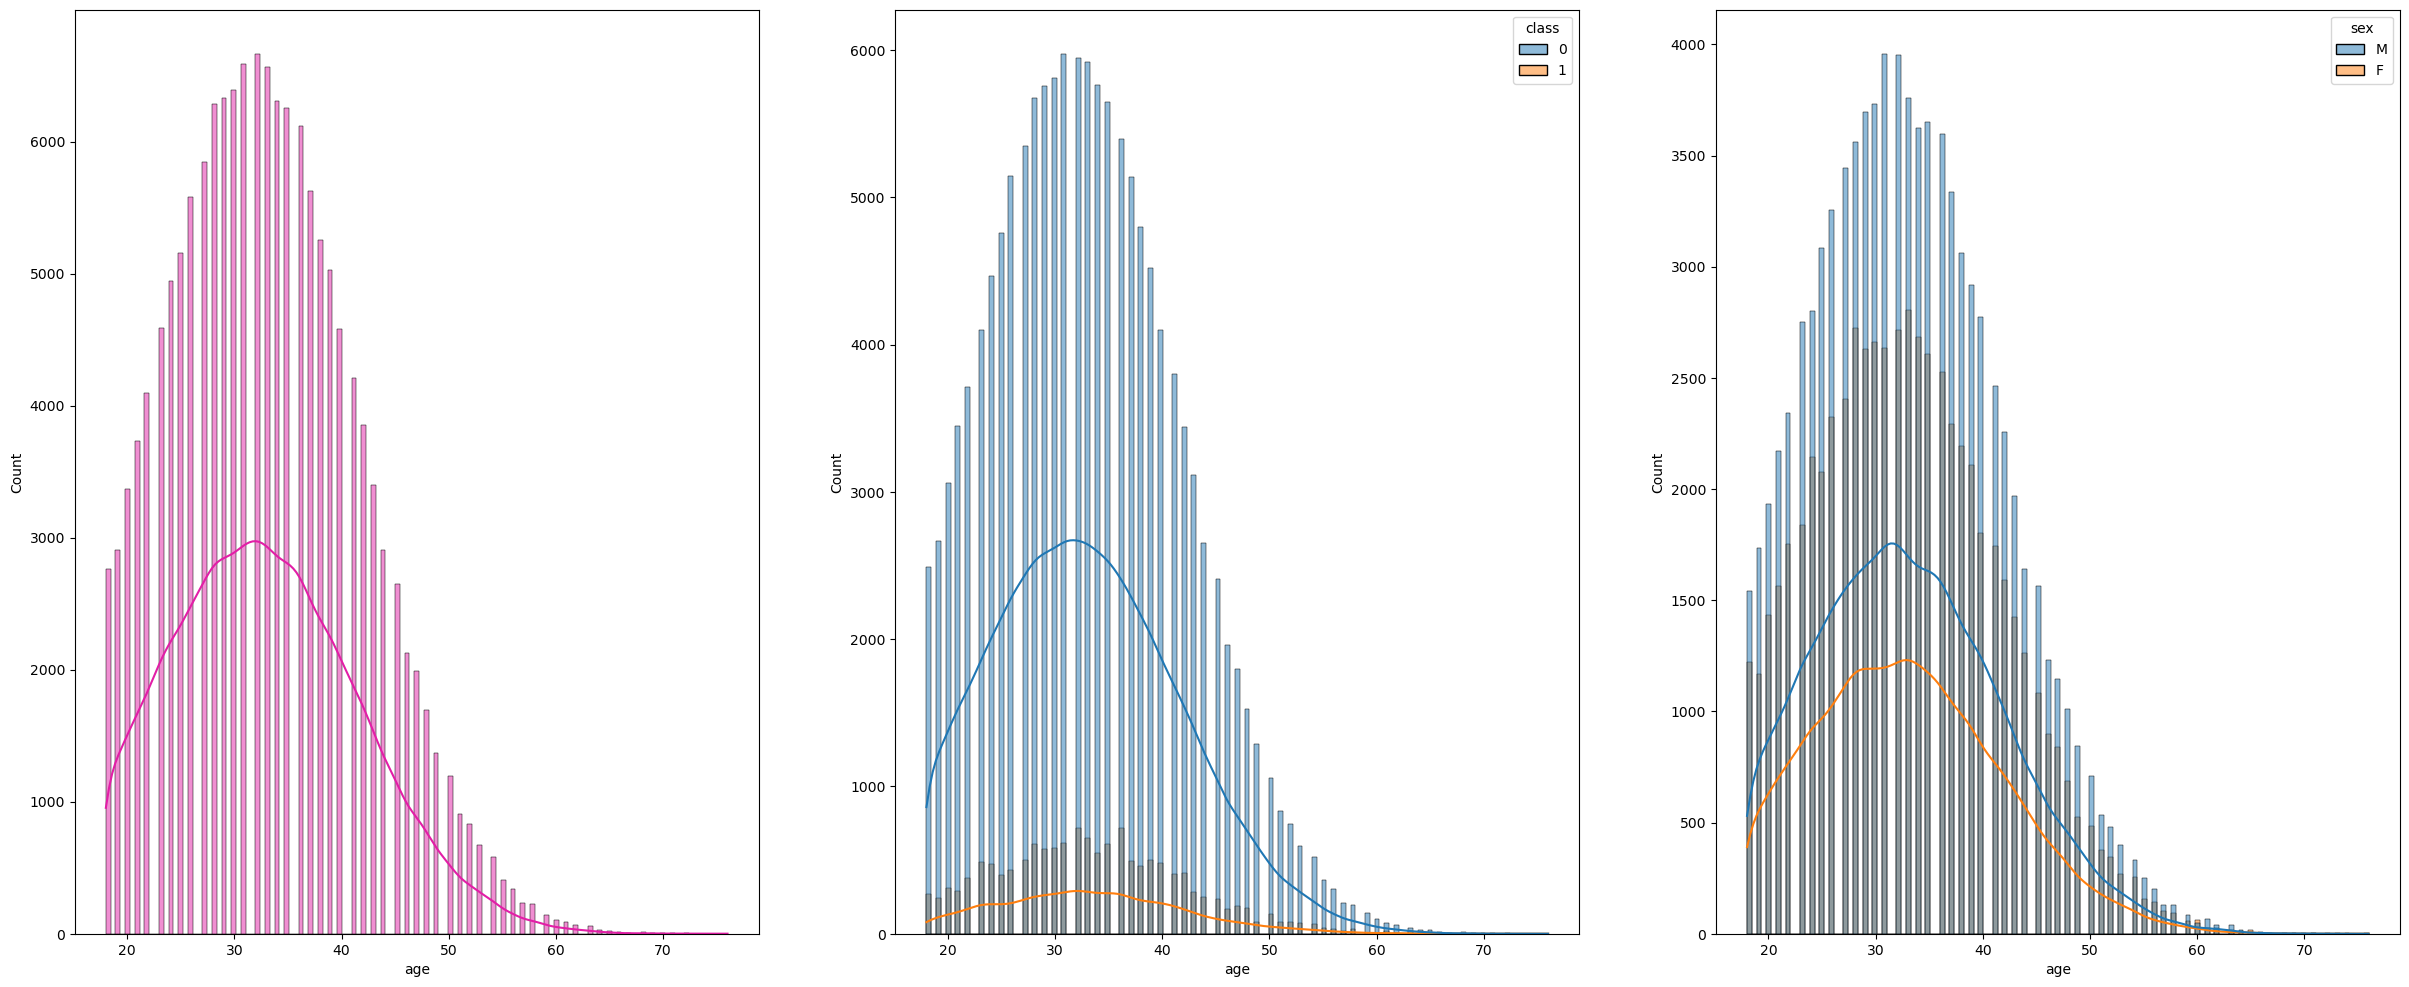

In [141]:
## age columns histplot
plt.figure(figsize=(25,8))
plt.subplots(1,3)

plt.subplot(1,3,1)
sns.histplot(data=df,x="age",kde=True,color="#E21EA7")

plt.subplot(1,3,2)
sns.histplot(data=df,x="age",hue="class",kde=True)

plt.subplot(1,3,3)
sns.histplot(data=df,x="age",hue="sex",kde=True)

plt.show()

# Insight
- 30-35 age customer has more
- 33-43 aged customer more likely to be fraud

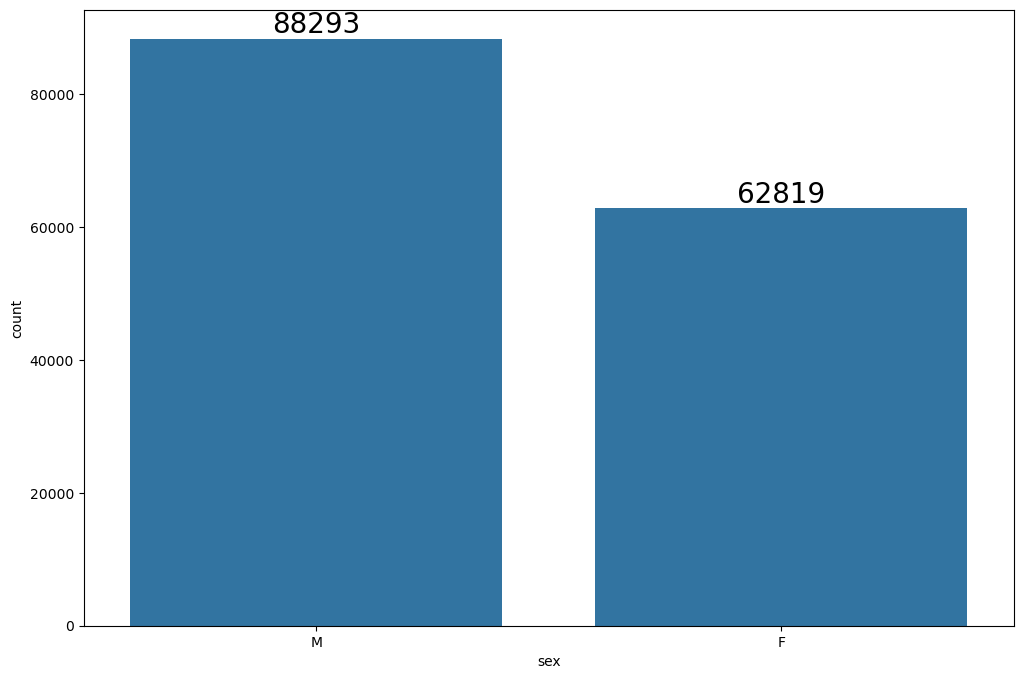

In [151]:
plt.figure(figsize=(12,8))
plot = sns.countplot(x=df["sex"])
for container in plot.containers:
    plot.bar_label(container,color='black',size=20)
plt.show()

# Insight
Male 88293 and Fmale 62819. Male Customer is more than Female Customer. <br>
that's way Male customer is more fraud

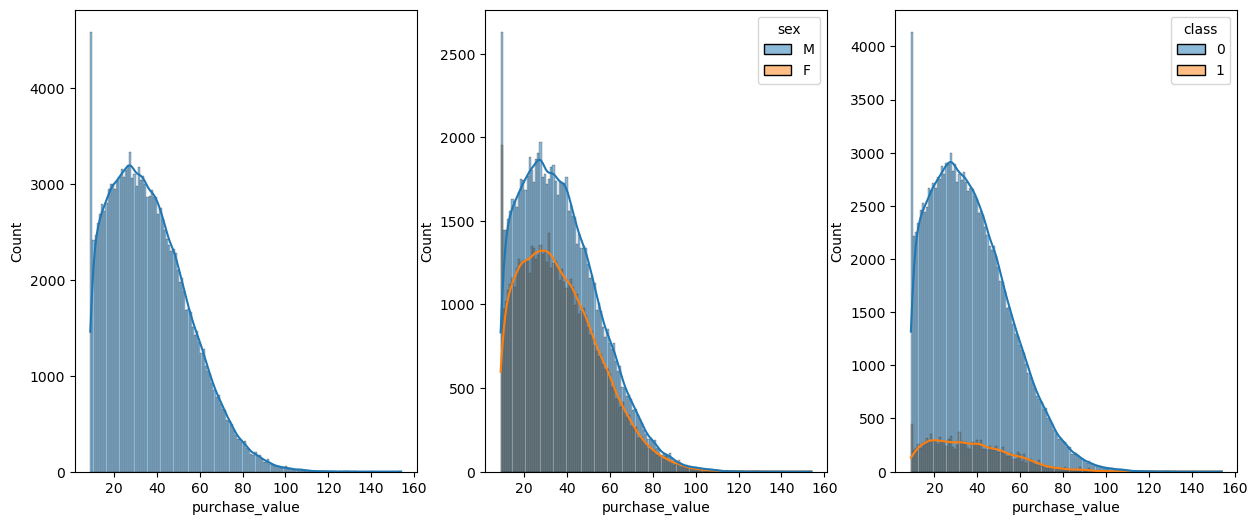

In [172]:

plt.subplots(1,3,figsize=(15,6))

plt.subplot(1,3,1)
sns.histplot(data=df,x="purchase_value",kde=True)

plt.subplot(1,3,2)
sns.histplot(data=df,x="purchase_value",kde=True,hue="sex")

plt.subplot(1,3,3)
sns.histplot(data=df,x="purchase_value",kde=True,hue="class")

plt.show()

# Insight
- 20-60 has more purchase values
- Male customer has more Puschase values
- Normal/ non fraud customer is more than fraud customer

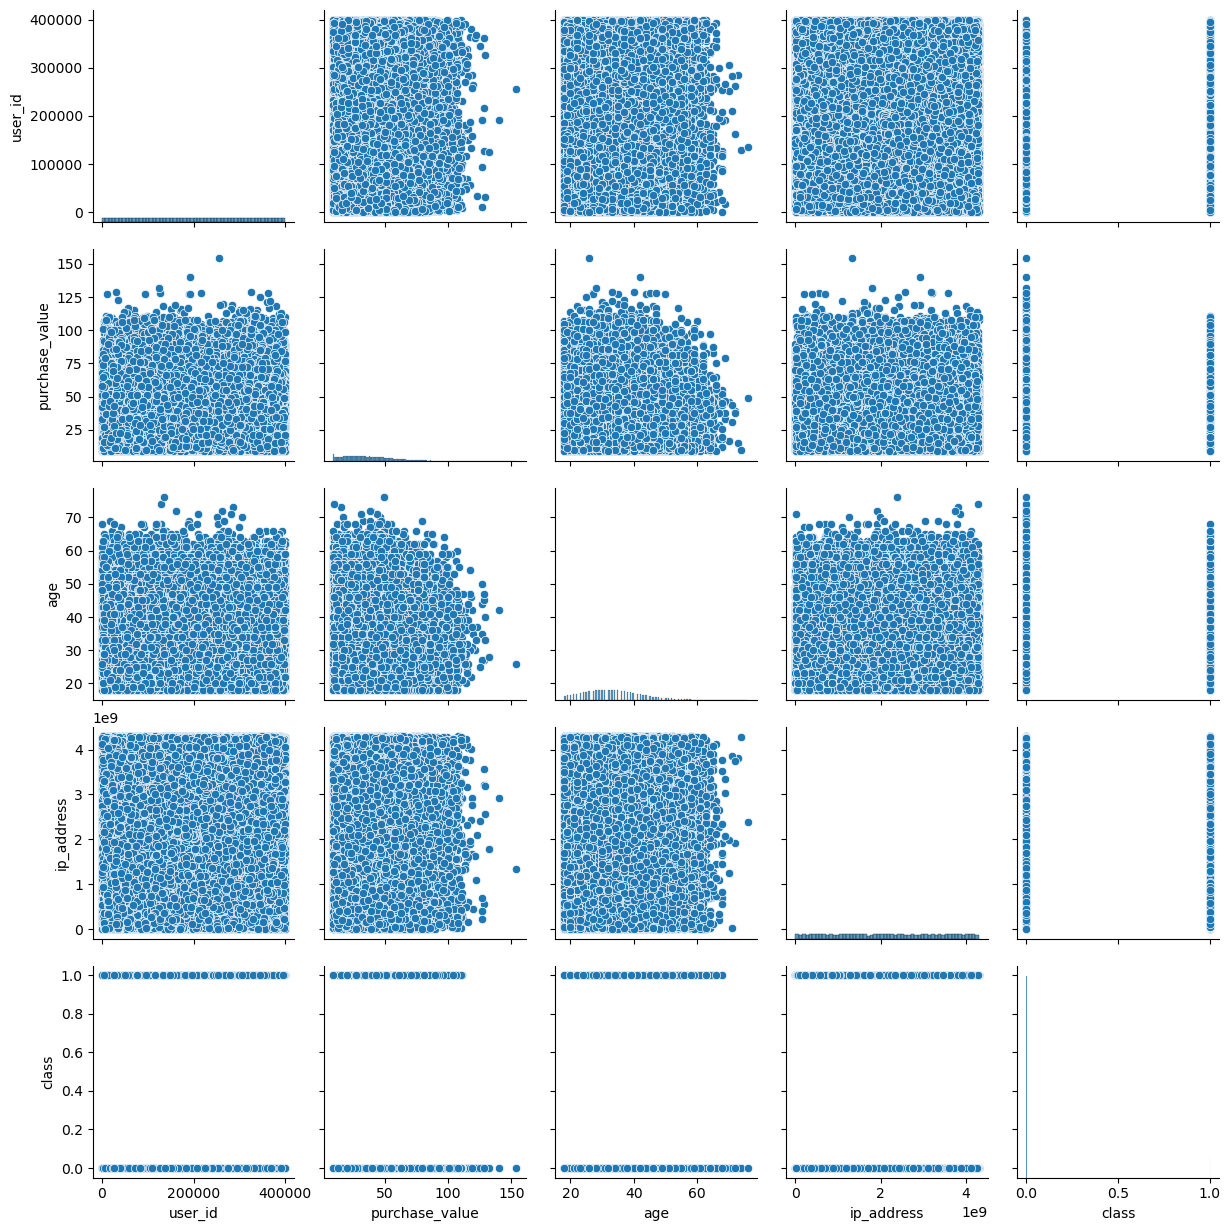

In [173]:
## mutivariate analysis
sns.pairplot(df)
plt.show()

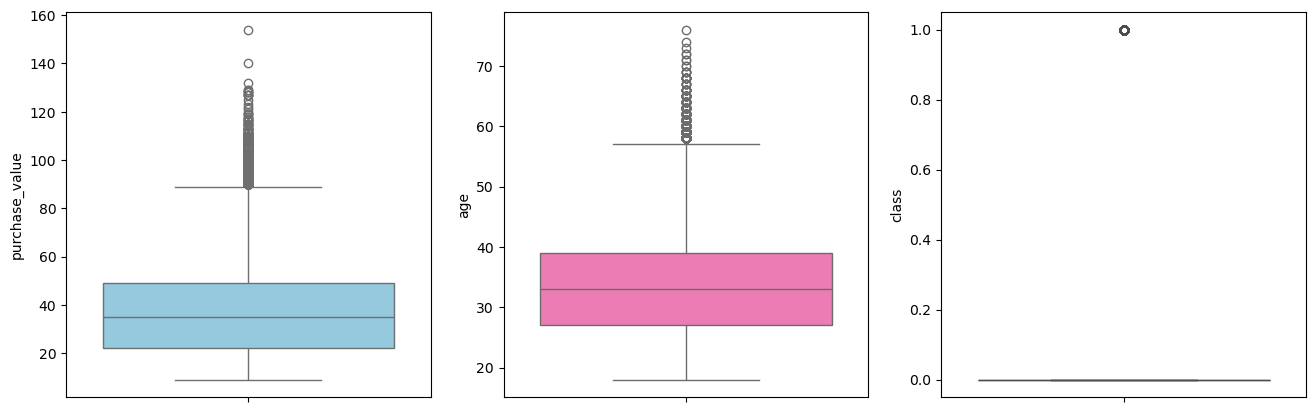

In [175]:
##check outliears
plt.subplots(1,3,figsize=(16,5))
plt.subplot(131)
sns.boxplot(df['purchase_value'],color='skyblue')
plt.subplot(132)
sns.boxplot(df['age'],color='hotpink')
plt.subplot(133)
sns.boxplot(df['class'],color='yellow')
plt.show()

In [89]:
## cheak target columns
df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [90]:
## show target columns values in percentage
percent = round(df['class'].value_counts(normalize=True)*100, 2)
percent

class
0    90.64
1     9.36
Name: proportion, dtype: float64

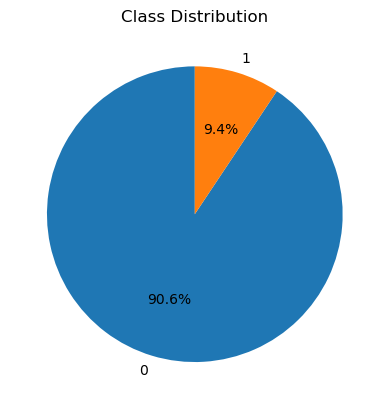

In [91]:
# visualize percentage
plt.pie(percent, labels=percent.index, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution')
plt.show()

__________________